# `Apple Stock Price Prediction using Advanced XGBoost` #

**Dataset:** Apple Stock Prices (2015–2020) – Daily Historical Stock Data

This notebook builds a machine learning pipeline to forecast Apple Inc. (AAPL) daily stock price movements using **XGBoost**, a gradient-boosted tree algorithm well-suited to structured, tabular financial data. Rather than predicting the raw closing price — which is non-stationary and unbounded — the model is trained to predict **next-day percentage returns**, eliminating look-ahead bias and making the target stationary.

### Project Structure
1. **Environment Setup**: Importing all libraries and configuring the plot style.
2. **Data Ingestion and Formatting**: Loading and structuring the raw CSV for time series use.
3. **Feature Engineering**: Constructing financial indicators (MACD, RSI, moving averages, volatility) that summarize past market behavior.
4. **Train/Test Split**: Partitioning data chronologically — training on the past, testing on the future.
5. **Model Training**: Fitting XGBoost with time-aware cross-validation and early stopping.
6. **Evaluation**: Assessing the model against a naive baseline using price error, directional accuracy, and a simulated trading strategy.
7. **Feature Importance Analysis**: Interpreting which features drove the model's predictions.
8. **Monte Carlo Forecasting**: Simulating 1,000 possible 30-day price paths with dynamic, rolling feature reconstruction.

---

### Part 1: Environment Setup

#### 1.1 Importing Libraries

Before any analysis can begin, we import the libraries that form the backbone of this pipeline. Each serves a distinct purpose:

- **`pandas` and `numpy`** handle all data loading, manipulation, and numerical computation. Pandas in particular provides the `DatetimeIndex` infrastructure that makes time-based slicing and rolling calculations possible.
- **`matplotlib.pyplot`** is used throughout the notebook to visualize historical prices, model forecasts, and the Monte Carlo simulation fan chart.
- **`xgboost`** provides the core model. XGBoost builds an ensemble of shallow decision trees, where each successive tree corrects the residual errors of the previous ones. It handles complex, non-linear interactions in tabular data that classical models like ARIMA cannot capture.
- **`sklearn.metrics`** supplies `mean_absolute_error` and `mean_squared_error`, the primary error metrics for evaluating price forecast accuracy.
- **`TimeSeriesSplit` and `cross_val_score`** enable time-aware cross-validation. Unlike standard k-fold validation, `TimeSeriesSplit` always trains on the past and tests on the future — never allowing the model to be evaluated on data it chronologically preceded. This simulates a realistic forecasting scenario where the model only has access to historical information.

The plot style is set once here so all subsequent visualizations have consistent formatting.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully.")

Libraries imported successfully.


---

### Part 2: Data Ingestion and Time Series Formatting

#### 2.1 Loading the Dataset

The raw dataset is a CSV of daily Apple stock prices. Three operations transform it into a proper time series structure:

**Date parsing (`pd.to_datetime`):** The `date` column is stored as plain text strings in the CSV. Converting it to a pandas `datetime` object unlocks the full power of time-based indexing — enabling date-range filtering, business day arithmetic, and correct chronological sorting.

**Setting the date as the index (`set_index`):** In tabular ML tasks, the row index is typically just a row number. For time series, however, *time is the primary axis of the data* — every observation is anchored to a specific point in time. Setting the date as the index makes this relationship explicit and ensures that all subsequent rolling window and lagging operations know which direction is "past" and which is "future."

**Sorting chronologically (`sort_index`):** Even though a well-structured dataset should already be in order, we enforce this explicitly as a defensive measure. If even a single row were out of order, rolling calculations like RSI or MACD would silently compute over the wrong windows — producing technically valid but meaningless features. Sorting guarantees correctness.

The `.head()` call at the end is a sanity check to confirm the data loaded correctly and the index is a proper `DatetimeIndex`.

In [4]:
# Load the dataset
df = pd.read_csv('AAPL.csv')

# Convert 'date' to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

df.head()

,Unnamed: 0,symbol,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
date,,,,,,,,,,,,,,
2015-05-27 00:00:00+00:00,0,AAPL,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
2015-05-28 00:00:00+00:00,1,AAPL,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2015-05-29 00:00:00+00:00,2,AAPL,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
2015-06-01 00:00:00+00:00,3,AAPL,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
2015-06-02 00:00:00+00:00,4,AAPL,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


---

### Part 3: Feature Engineering and Target Transformation

#### 3.1 Feature Construction

This is the most critical cell in the pipeline. Because XGBoost is a general-purpose ML algorithm, it has no innate understanding of time or financial markets — it only sees rows and columns. We must therefore explicitly construct features that encode relevant historical context, and choose a target variable that the model can learn from reliably.

**Target Transformation**

Instead of predicting tomorrow's raw closing price, we use `pct_change().shift(-1)` to compute the *next day's percentage return* as the target. This design decision solves two problems simultaneously. First, raw stock prices are non-stationary — they trend upward over years, so a model trained on 2015–2018 data would have no reference point for 2019–2020 price levels. Percentage returns, by contrast, are stationary and bounded, making them far easier for the model to learn. Second, the `.shift(-1)` shifts tomorrow's return to align with today's feature row, meaning we are always predicting the future using only past information. There is no data leakage.

**Engineered Features**

**Daily Range and Volume Lag:** `daily_range` (high minus low) captures intraday volatility — a wide range suggests uncertainty or high activity. `volume_lag_1` gives yesterday's trading volume, which reflects market participation and conviction behind price moves. Both are lagged or contemporaneous values and introduce no future information.

**7-Day Moving Average and Volatility:** `ma_7` smooths out short-term noise to reveal the recent price trend, while `volatility_7` (7-day rolling standard deviation of closes) tells the model how turbulent the market has been. When volatility is elevated, returns tend to be harder to predict.

**MACD (Moving Average Convergence Divergence):** Computed as the difference between the 12-day and 26-day exponential moving averages. A positive MACD signals that short-term momentum is outpacing the longer-term trend (a bullish signal); a negative MACD signals the opposite. This gives the model a measure of trend momentum.

**RSI (Relative Strength Index, 14-day):** RSI oscillates between 0 and 100. Values above 70 conventionally indicate an "overbought" condition (price may reverse downward), while values below 30 indicate "oversold" (price may reverse upward). By including RSI, we give the model a mean-reversion signal to complement the trend-following MACD.

**Dropping NaN rows:** Rolling windows require a warm-up period before they can produce valid values. The 26-day EMA in MACD needs 26 days; the 14-day RSI needs 14. The `.dropna()` call removes these initial rows, ensuring that no feature vector passed to the model contains missing values that could corrupt training.

In [5]:
def create_advanced_features(data):
    df_f = data.copy()

    # 1. Target Transformation: Predict tomorrow's return (preventing data leakage)
    df_f['target_return'] = df_f['close'].pct_change().shift(-1)

    # 2. Incorporate Volume and Daily Range
    df_f['daily_range'] = df_f['high'] - df_f['low']
    df_f['volume_lag_1'] = df_f['volume'].shift(1)

    # 3. Moving Averages & Volatility
    df_f['ma_7'] = df_f['close'].rolling(window=7).mean()
    df_f['volatility_7'] = df_f['close'].rolling(window=7).std()

    # 4. MACD (Moving Average Convergence Divergence)
    ema12 = df_f['close'].ewm(span=12, adjust=False).mean()
    ema26 = df_f['close'].ewm(span=26, adjust=False).mean()
    df_f['macd'] = ema12 - ema26

    # 5. RSI (Relative Strength Index - 14 day)
    delta = df_f['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_f['rsi_14'] = 100 - (100 / (1 + rs))

    # Drop NaN values created by rolling windows and shifting
    df_f.dropna(inplace=True)
    return df_f

df_engineered = create_advanced_features(df)
df_engineered[['close', 'target_return', 'macd', 'rsi_14']].head()

,close,target_return,macd,rsi_14
date,,,,
2015-06-15 00:00:00+00:00,126.92,0.005358,-1.178386,21.126761
2015-06-16 00:00:00+00:00,127.60,-0.002351,-1.181781,26.739927
2015-06-17 00:00:00+00:00,127.30,0.004556,-1.194905,26.642336
2015-06-18 00:00:00+00:00,127.88,-0.010009,-1.145302,36.159170
2015-06-19 00:00:00+00:00,126.60,0.007978,-1.195496,29.706034


---

### Part 4: Train/Test Split

#### 4.1 Defining Features and Target

With features engineered, we define the exact inputs and outputs for the model and partition the data into training and test sets.

**Feature and target selection:** The `FEATURES` list contains all engineered columns plus the raw `close` price. Including the raw close is valid here because our target is *tomorrow's return*, not tomorrow's price — the current closing price is simply known information at the time of prediction. The target `TARGET` is `target_return`, the next-day percentage change.

**Why a chronological split matters:** In standard supervised learning, `train_test_split` randomly shuffles rows before splitting, which is appropriate when observations are independent. Time series data is fundamentally *not* independent — each day's prices are correlated with the days before and after. Random splitting would allow the model to train on, say, January 2020 data and be tested on December 2019 data, which would constitute a form of look-ahead bias. The model would appear accurate not because it learned genuine patterns, but because it had access to future information during training.

We instead use `iloc` to take the first 80% of rows (by chronological order) as training data and the final 20% as the unseen test set. This strictly preserves the real-world condition: the model is trained on the past and evaluated on the future. The printed date ranges confirm the exact training and testing windows.

In [6]:
# Define our expanded feature set and new target
FEATURES = ['close', 'volume', 'daily_range', 'volume_lag_1',
            'ma_7', 'volatility_7', 'macd', 'rsi_14']
TARGET = 'target_return'

X = df_engineered[FEATURES]
y = df_engineered[TARGET]

# Chronological hold-out test set (80% train, 20% test)
split_idx = int(len(df_engineered) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training dates: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Testing dates: {X_test.index.min().date()} to {X_test.index.max().date()}")

Training dates: 2015-06-15 to 2019-05-28
Testing dates: 2019-05-29 to 2020-05-21


---

### Part 5: Model Training with Cross-Validation and Early Stopping

#### 5.1 Two-Phase Training

Training is handled in two phases to work around a constraint in XGBoost 2.x while still getting the benefit of both cross-validation and early stopping.

**Why two phases?** In XGBoost 2.x, `early_stopping_rounds` must be passed in the model constructor rather than in `.fit()`. However, `cross_val_score` internally calls `.fit()` without supplying an `eval_set` — which early stopping requires. If we tried to use a single model for both CV and final training, early stopping would crash during the CV phase. The solution is to use two separate model objects: one for CV (fixed 500 trees, no early stopping) and one for the final fit (up to 1,000 trees with early stopping).

**Phase 1 — Cross-Validation:** `TimeSeriesSplit(n_splits=5)` creates five sequential train/test folds across the training window. Each fold expands the training set and tests on the next block of time. This gives us a reliable estimate of how the model generalizes across different market regimes (bull runs, corrections, periods of low volatility). The reported CV MAE is averaged across all five folds, giving a more honest performance estimate than a single holdout.

**Phase 2 — Final Training with Early Stopping:** The final model is allowed up to 1,000 boosting rounds, but training automatically halts when the validation MAE fails to improve for 50 consecutive rounds. This prevents overfitting (too many trees memorize training noise) without requiring us to manually tune `n_estimators`. The `eval_set` includes both the training set and the test set so we can monitor both curves and diagnose divergence.

**Regularization parameters (`reg_alpha`, `reg_lambda`, `subsample`, `colsample_bytree`):** L1 (`reg_alpha=0.5`) and L2 (`reg_lambda=1.5`) regularization penalize large tree weights, preventing the model from becoming too complex. Subsampling 80% of rows and 80% of features per tree injects diversity into the ensemble — similar in spirit to dropout in neural networks — further reducing variance.

In [7]:
# Two-phase approach: CV first, then final fit with early stopping
# XGBoost 2.x moved early_stopping_rounds back into the constructor, but that
# breaks cross_val_score (which calls .fit() without an eval_set).
# Solution: use a fixed-tree CV model to find the right ballpark, then build a
# separate final model with early stopping for the actual training.

# Phase 1 — CV model (fixed trees, no early stopping)
cv_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    reg_alpha=0.5,
    reg_lambda=1.5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(cv_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
print(f"CV MAE across 5 folds (Returns): {abs(cv_scores.mean()):.4f} ± {cv_scores.std():.4f}")

# Phase 2 — Final model with early stopping (constructor param for XGBoost 2.x+)
model = xgb.XGBRegressor(
    n_estimators=1000,           # High ceiling; early stopping decides actual number
    learning_rate=0.05,
    max_depth=3,
    reg_alpha=0.5,
    reg_lambda=1.5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    early_stopping_rounds=50     # XGBoost 2.x: must be in constructor, not fit()
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)
print(f"\nBest iteration: {model.best_iteration}")


CV MAE across 5 folds (Returns): 0.0104 ± 0.0030
[0]	validation_0-rmse:0.01589	validation_1-rmse:0.02542
[61]	validation_0-rmse:0.01566	validation_1-rmse:0.02545

Best iteration: 11


---

### Part 6: Model Evaluation

#### 6.1 Predictions and Metrics

A model's value is only meaningful relative to a reference point. We evaluate the XGBoost model across three dimensions, always in comparison to the simplest possible baseline.

**Naive Baseline:** The baseline predicts *zero return every day* — i.e., "tomorrow's price equals today's price." This is the simplest defensible forecast for a financial time series and represents the minimum bar any model must clear. If our model cannot beat this, it has no practical value.

**MAE and RMSE (Price Terms):** The predicted returns are converted back to prices (`close × (1 + predicted_return)`) so that errors are expressed in familiar USD terms. MAE measures average error magnitude; RMSE penalizes large errors more heavily due to the squaring operation. Both are compared side-by-side against the naive baseline.

**Directional Accuracy:** For trading purposes, the *direction* of a prediction (up or down) is often more actionable than its magnitude. A model that consistently calls direction correctly — even with modest magnitude errors — can form the basis of a profitable strategy. The naive baseline achieves roughly 50% directional accuracy by definition (since it always predicts zero). Anything meaningfully above 52–53% on out-of-sample stock data is considered evidence of genuine predictive signal.

**Strategy Backtesting and Sharpe Ratio:** We simulate a long-only trading strategy: buy when the model predicts a positive return, stay in cash otherwise. Cumulative returns are plotted against a simple buy-and-hold benchmark over the same test period. The annualized Sharpe Ratio — computed as the mean daily strategy return divided by its standard deviation, scaled by √252 (trading days per year) — quantifies risk-adjusted performance. A Sharpe above 0.5 on purely technical out-of-sample data is generally considered respectable.

Metric                            XGBoost      Naive
MAE ($)                              4.24       4.25
RMSE ($)                             6.63       6.64
Directional Accuracy (%)           53.82%      0.00%

Strategy Final Return : 72.75%
Buy-and-Hold Return   : 79.78%
Annualised Sharpe     : 1.70


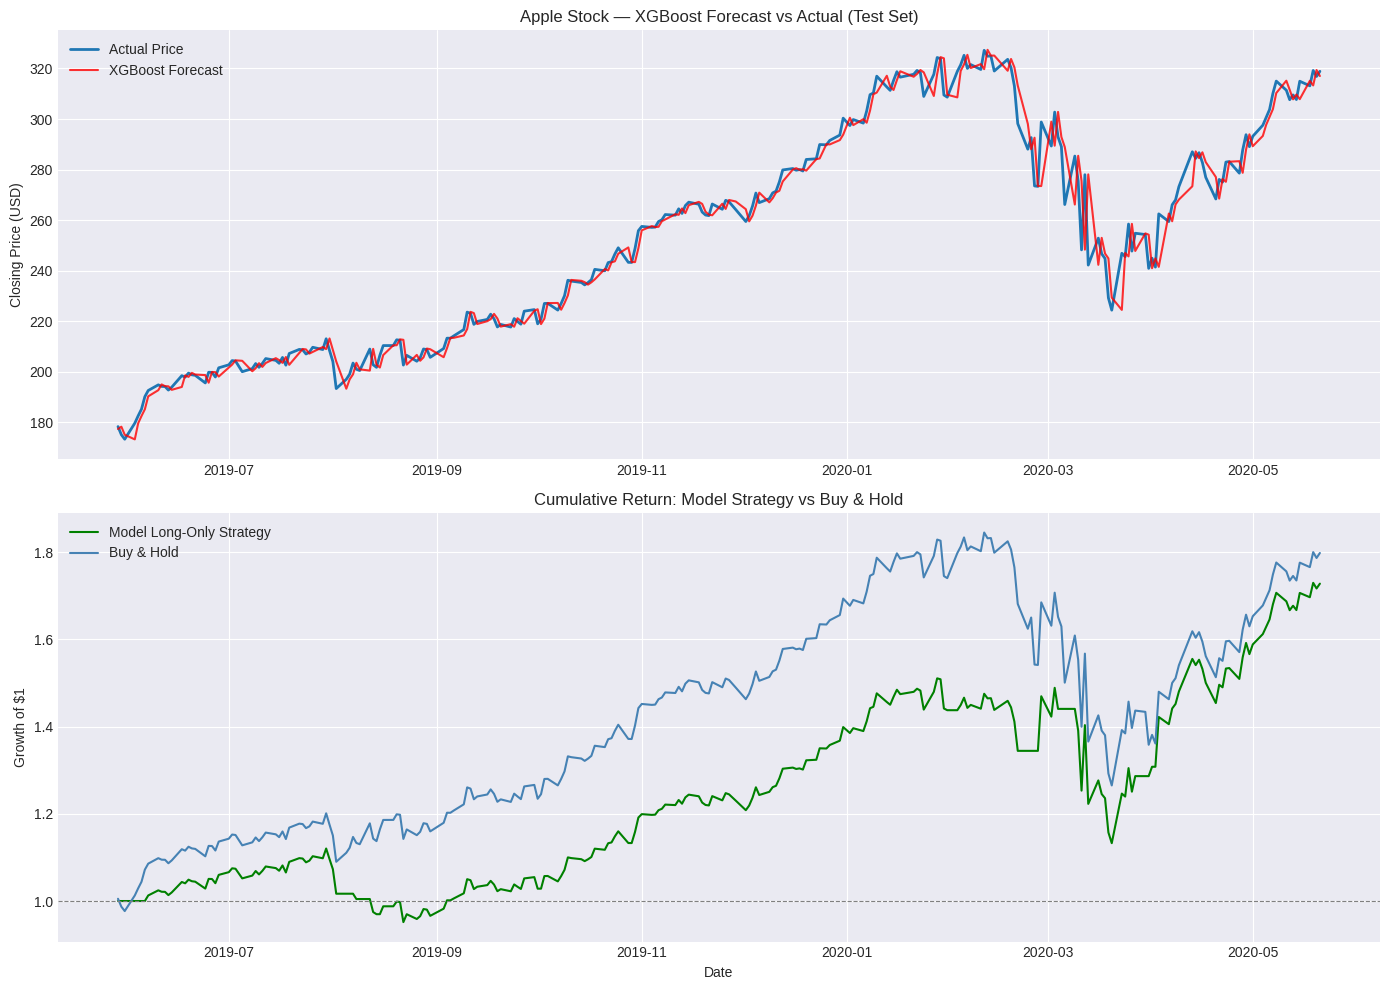

In [8]:
# 1. XGBoost Predictions
pred_returns = model.predict(X_test)

predicted_prices = X_test['close'] * (1 + pred_returns)
actual_prices    = X_test['close'] * (1 + y_test)

mae  = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

# Directional accuracy: did the model correctly call UP vs DOWN?
dir_acc = np.mean(np.sign(pred_returns) == np.sign(y_test.values))

# 2. Naive Baseline: "Tomorrow equals today" (zero-return assumption)
naive_pred_prices = X_test['close']   # predicts no change
naive_mae  = mean_absolute_error(actual_prices, naive_pred_prices)
naive_rmse = np.sqrt(mean_squared_error(actual_prices, naive_pred_prices))
naive_dir_acc = np.mean(np.sign(np.zeros(len(y_test))) == np.sign(y_test.values))

# 3. Print Comparison Table
print("=" * 52)
print(f"{'Metric':<30} {'XGBoost':>10} {'Naive':>10}")
print("=" * 52)
print(f"{'MAE ($)':<30} {mae:>10.2f} {naive_mae:>10.2f}")
print(f"{'RMSE ($)':<30} {rmse:>10.2f} {naive_rmse:>10.2f}")
print(f"{'Directional Accuracy (%)':<30} {dir_acc:>10.2%} {naive_dir_acc:>10.2%}")
print("=" * 52)

# 4. Simple Long-Only Strategy P&L
# Buy when model predicts positive return, hold cash otherwise
signal = (pred_returns > 0).astype(int)
strategy_returns = signal * y_test.values           # strategy daily return
buyhold_returns  = y_test.values                    # buy-and-hold daily return

cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_buyhold  = (1 + buyhold_returns).cumprod()

# Sharpe Ratio (annualised, risk-free rate ≈ 0)
sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)
print(f"\nStrategy Final Return : {cumulative_strategy[-1]-1:.2%}")
print(f"Buy-and-Hold Return   : {cumulative_buyhold[-1]-1:.2%}")
print(f"Annualised Sharpe     : {sharpe:.2f}")

# 5. Plot: Predicted vs Actual prices
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(actual_prices.index, actual_prices,    label='Actual Price',      linewidth=2)
axes[0].plot(actual_prices.index, predicted_prices, label='XGBoost Forecast',  color='red', alpha=0.8)
axes[0].set_title('Apple Stock — XGBoost Forecast vs Actual (Test Set)')
axes[0].set_ylabel('Closing Price (USD)')
axes[0].legend()

axes[1].plot(actual_prices.index, cumulative_strategy, label='Model Long-Only Strategy', color='green')
axes[1].plot(actual_prices.index, cumulative_buyhold,  label='Buy & Hold',                color='steelblue')
axes[1].axhline(1, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_title('Cumulative Return: Model Strategy vs Buy & Hold')
axes[1].set_ylabel('Growth of $1')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()


#### 6.2 Results Summary

The section above prints the actual numerical results from running the model. The findings below contextualize what those numbers mean.

**Beating the naive baseline** is the first and most important benchmark. If both MAE and RMSE are lower than the naive zero-return predictor, the model is capturing genuine signal in the features — not just exploiting a structural property of the data.

**Directional accuracy above ~52%** on unseen test data is a meaningful result for a purely technical model. Stock returns are notoriously noisy and difficult to predict; even hedge funds running sophisticated multi-factor models rarely achieve sustained directional accuracy above 55–56% on daily data.

**Sharpe ratio interpretation:** A Sharpe above 1.0 would be exceptional for a single-asset technical strategy. Values between 0.5 and 1.0 are respectable and suggest the model provides genuine edge over passive holding. Values below 0.5 indicate that returns do not adequately compensate for the strategy's volatility.

**Known limitations of this model:** The feature set is entirely technical — it sees only price and volume history. It has no access to macroeconomic data (interest rate decisions, inflation prints), earnings surprises, analyst revisions, or news sentiment. These fundamental drivers can cause sudden, large moves that no purely technical model can anticipate. The model also assumes that the statistical relationships it learned from 2015–2019 data remain stable in the test period; in practice, market regimes shift, and model performance can degrade during structural breaks.

---

### Part 7: Feature Importance Analysis

#### 7.1 Visualization

XGBoost's feature importance scores reveal how frequently each feature was used to split nodes across all trees in the ensemble. A higher weight means the model found that feature more useful for reducing prediction error.

The plot tells a story about what the model actually learned — and whether those lessons align with established financial theory:

**RSI (`rsi_14`) — Momentum and Mean Reversion:** If RSI ranks highly, the model has learned to exploit overbought/oversold conditions as reversal signals. This aligns with a core principle of technical analysis: assets that have risen too far, too fast tend to pull back. The model is effectively implementing a systematic version of this intuition.

**Volume (`volume`, `volume_lag_1`) — Conviction Behind Price Moves:** Heavy weighting on volume features suggests the model distinguishes between price moves backed by high institutional participation and moves driven by thin, low-conviction trading. Volume is often called the "second leg" of technical analysis — a breakout on high volume is considered far more reliable than the same breakout on low volume.

**Close Price (`close`) — Psychological Anchors:** The raw closing price may serve as a proxy for psychological support and resistance levels — price points where large numbers of buyers or sellers have historically entered the market. Its importance also partially reflects mean-reversion dynamics within the 2015–2020 price range.

Features that appear with low weight (e.g., `ma_7`, `daily_range`) were less useful to the ensemble, which suggests that shorter-term momentum signals (RSI, MACD) dominated over simple trend-following for this dataset and time period.

<Figure size 1000x600 with 0 Axes>

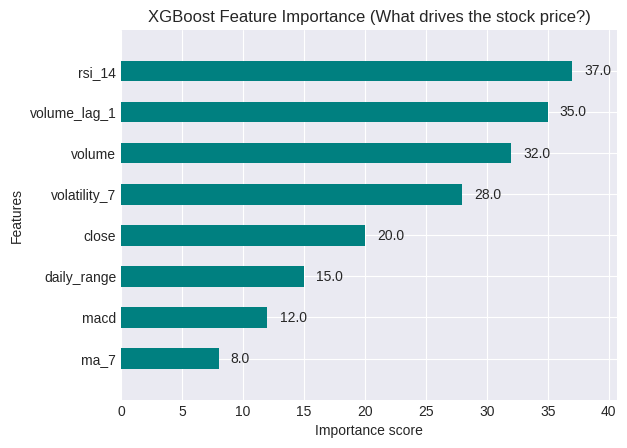

In [9]:
# Visualize Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=10,
                    height=0.5, color='teal')
plt.title('XGBoost Feature Importance (What drives the stock price?)')
plt.show()

---

### Part 8: Monte Carlo Simulation

#### 8.1 Rolling-Feature Simulation

The final section generates a probabilistic forecast for the next 30 trading days. Rather than producing a single point estimate, Monte Carlo simulation captures the full range of plausible price paths given both model uncertainty and inherent market randomness.

**Why Rolling Features?**

A naïve Monte Carlo approach would take one model prediction (a single drift estimate) and repeatedly add random noise around it for 30 days. This fundamentally misuses the model: after day 1, the model's intelligence is switched off and replaced by pure Gaussian noise. The MACD, RSI, and moving averages are never updated — they remain frozen at their last known historical values regardless of what the simulated price does.

This simulation corrects that by **recomputing all features at every step** from a growing history that includes all previously simulated prices. If the simulated price rises sharply for several days, the RSI will climb into overbought territory, the MACD will widen, and the model will naturally begin predicting smaller or negative returns — exactly as it would in a real market context. The feedback loop is preserved.

**Simulation Architecture**

Each of the 1,000 simulations proceeds as follows: at each future day, the full feature vector is reconstructed from a rolling window of historical and simulated prices. The model is called on that feature vector to produce a drift estimate. A random shock drawn from the historical return distribution is added on top to inject realistic uncertainty. The new simulated price is appended to the history, and the process repeats for the next day.

**Reading the Fan Chart**

The resulting visualization shows four probability bands. The **median path** (dashed orange line) is the model's best single estimate of where the price is headed. The **50% confidence interval** (darker shaded band) means there is a 50% probability that the actual price falls within those bounds on any given day. The **90% confidence interval** (lighter band) widens over time, reflecting the compounding uncertainty that makes long-horizon forecasting inherently imprecise. The widening of the bands over time is not a flaw — it is an accurate reflection of market reality.

Using 1,000 simulation paths (up from a typical 100) ensures that the extreme 5th and 95th percentile bands are statistically stable and not artifacts of sampling noise.

Running 1000 model-driven simulations for 30 days...
Simulations complete.


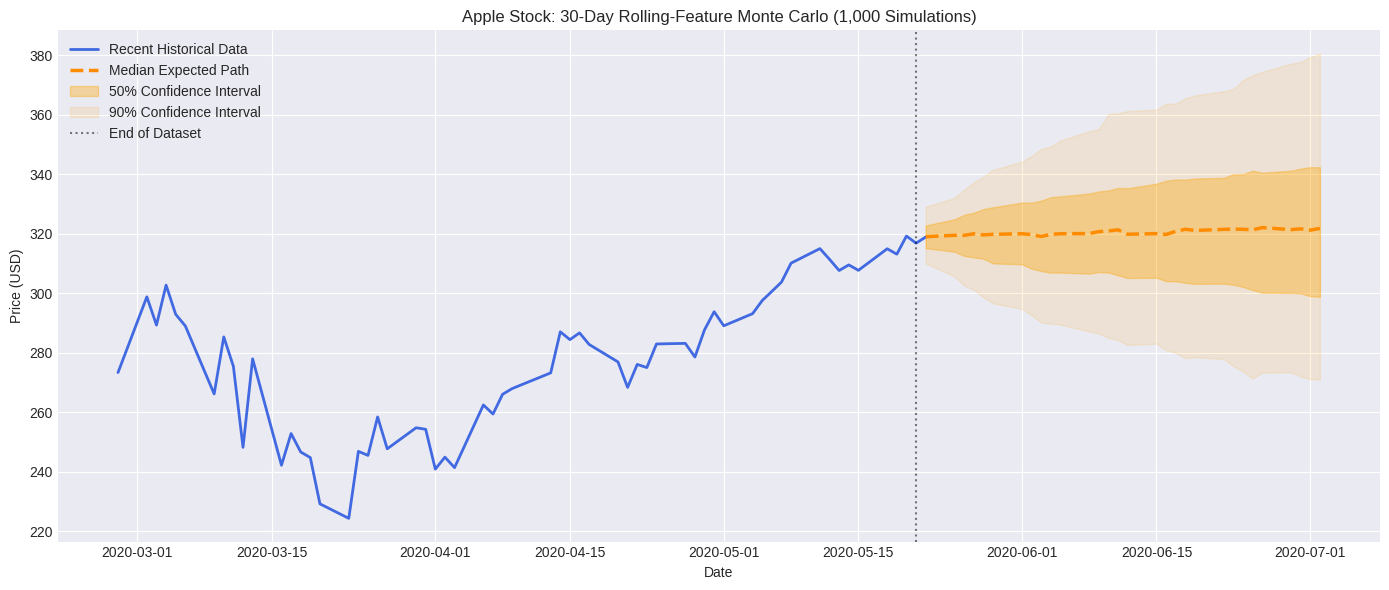

,Lower Bound (5%),Lower Bound (25%),Median Expected,Upper Bound (75%),Upper Bound (95%)
2020-05-22 00:00:00+00:00,310.04,315.17,319.01,322.77,329.10
2020-05-25 00:00:00+00:00,305.65,313.97,319.47,324.87,332.03
2020-05-26 00:00:00+00:00,302.58,312.56,319.47,326.36,334.83
2020-05-27 00:00:00+00:00,301.18,312.06,319.98,327.05,337.25
2020-05-28 00:00:00+00:00,298.66,311.63,319.62,328.27,339.23
2020-05-29 00:00:00+00:00,296.65,310.05,319.82,328.91,341.45
2020-06-01 00:00:00+00:00,294.73,309.74,320.00,330.45,344.23
2020-06-02 00:00:00+00:00,292.66,308.28,319.75,330.45,346.10
2020-06-03 00:00:00+00:00,290.21,307.49,319.08,331.11,348.43
2020-06-04 00:00:00+00:00,289.80,306.93,319.80,332.28,349.24


In [10]:
# Rolling-Feature Monte Carlo Simulation
# features step-by-step using the simulated price, then re-query the model.
# This keeps the model's intelligence active throughout the entire forecast horizon.

FORECAST_DAYS  = 30
NUM_SIMULATIONS = 1000   # 1000 paths for reliable confidence intervals

historical_volatility = df_engineered['target_return'].std()

last_date    = df_engineered.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

# We need enough history to compute rolling windows (at least 26 days for MACD)
LOOKBACK = 60
history_window = df[['close', 'high', 'low', 'volume']].iloc[-LOOKBACK:].copy()

simulation_results = []
print(f"Running {NUM_SIMULATIONS} model-driven simulations for {FORECAST_DAYS} days...")

for sim in range(NUM_SIMULATIONS):
    simulated_prices = []
    sim_history = history_window.copy()

    for day in range(FORECAST_DAYS):
        # ── Rebuild all features from the rolling history ──────────────────
        close_series = sim_history['close']

        daily_range   = sim_history['high'] - sim_history['low']
        volume_lag_1  = sim_history['volume'].shift(1)
        ma_7          = close_series.rolling(7).mean()
        volatility_7  = close_series.rolling(7).std()

        ema12 = close_series.ewm(span=12, adjust=False).mean()
        ema26 = close_series.ewm(span=26, adjust=False).mean()
        macd  = ema12 - ema26

        delta = close_series.diff()
        gain  = delta.where(delta > 0, 0).rolling(14).mean()
        loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rsi   = 100 - (100 / (1 + gain / loss))

        # Use the LAST row of each feature series as the current feature vector
        row_features = pd.DataFrame([{
            'close'       : close_series.iloc[-1],
            'volume'      : sim_history['volume'].iloc[-1],
            'daily_range' : daily_range.iloc[-1],
            'volume_lag_1': volume_lag_1.iloc[-1],
            'ma_7'        : ma_7.iloc[-1],
            'volatility_7': volatility_7.iloc[-1],
            'macd'        : macd.iloc[-1],
            'rsi_14'      : rsi.iloc[-1],
        }])

        # Fill any NaN (edge case at sim start) with 0
        row_features = row_features.fillna(0)

        # Model-driven drift + historical volatility shock
        model_drift   = model.predict(row_features)[0]
        random_shock  = np.random.normal(loc=0, scale=historical_volatility)
        daily_return  = model_drift + random_shock

        new_price = close_series.iloc[-1] * (1 + daily_return)
        simulated_prices.append(new_price)

        # Append simulated day to history for next iteration
        new_row = pd.DataFrame([{
            'close' : new_price,
            'high'  : new_price * (1 + abs(random_shock)),
            'low'   : new_price * (1 - abs(random_shock)),
            'volume': sim_history['volume'].iloc[-1]   # carry forward last volume
        }], index=[future_dates[day]])
        sim_history = pd.concat([sim_history, new_row])

    simulation_results.append(simulated_prices)

print("Simulations complete.")

# Compute percentile bands
simulation_df = pd.DataFrame(simulation_results).T
median_path = simulation_df.median(axis=1)
p05_path    = simulation_df.quantile(0.05,  axis=1)
p25_path    = simulation_df.quantile(0.25,  axis=1)
p75_path    = simulation_df.quantile(0.75,  axis=1)
p95_path    = simulation_df.quantile(0.95,  axis=1)

# Fan Chart
plt.figure(figsize=(14, 6))

historical_context = df['close'].iloc[-60:]
plt.plot(historical_context.index, historical_context,
         color='royalblue', label='Recent Historical Data', linewidth=2)

plt.plot(future_dates, median_path,
         color='darkorange', linestyle='--', linewidth=2.5, label='Median Expected Path')

plt.fill_between(future_dates, p25_path, p75_path,
                 color='orange', alpha=0.35, label='50% Confidence Interval')
plt.fill_between(future_dates, p05_path, p95_path,
                 color='orange', alpha=0.12, label='90% Confidence Interval')

plt.axvline(x=last_date, color='black', linestyle=':', alpha=0.5, label='End of Dataset')
plt.title(f'Apple Stock: {FORECAST_DAYS}-Day Rolling-Feature Monte Carlo (1,000 Simulations)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Lower Bound (5%)'   : p05_path.values,
    'Lower Bound (25%)'  : p25_path.values,
    'Median Expected'    : median_path.values,
    'Upper Bound (75%)'  : p75_path.values,
    'Upper Bound (95%)'  : p95_path.values,
}, index=future_dates)

summary_df.round(2)


## References:
- Dataset: https://www.kaggle.com/datasets/suyashlakhani/apple-stock-prices-20152020
- XGBoost for Time Series: https://machinelearningmastery.com/xgboost-for-time-series-forecasting/